In [1]:
import os
import subprocess

repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(repo_root)

In [ ]:
import deeplay as dl
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from lightning.pytorch.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from torch_geometric.loader import DataLoader
from torchvision.transforms import Compose

from trajan.data import TracksDataFrame
from trajan.dataset import GraphDataset
from trajan.graph import GraphFromTrajectories
from trajan.transforms import RandomFlip, RandomRotation

In [3]:
tracks_path = os.path.join("data", "cytoplasmic_data", "tracks.csv")

data = pd.read_csv(tracks_path, skiprows=1)
data = TracksDataFrame(data, frame_rate=10)

data_description = data.describe_tracks()
display_labels = data_description["particle_types"]

{
  "particle_types": [
    "endosome",
    "golgi",
    "postgolgi"
  ],
  "frame_rate": 10,
  "endosome": {
    "n_recordings": 20,
    "n_tracks": "339",
    "avg_track_len": 130.65
  },
  "golgi": {
    "n_recordings": 7,
    "n_tracks": "103",
    "avg_track_len": 142.37
  },
  "postgolgi": {
    "n_recordings": 11,
    "n_tracks": "131",
    "avg_track_len": 131.94
  }
}


In [4]:
test_size = 0.25
seed = 42
Dt = 50
max_frame_distance = 3

train_data, val_data = data.split_train_test(test_size=test_size, seed=seed)

graph_builder, position_scale = GraphFromTrajectories.from_tracks(
    train_data, Dt, max_frame_distance
)

train_graphs = graph_builder(train_data, target_column="type", split_tracks=True)
val_graphs = graph_builder(val_data, target_column="type", split_tracks=True)

/Users/guillemguigoicorominas/Desktop/Guillem/UVic/PhD/repositories/personal/ParticleClassification/trajan/data.py:145: UserWarning: No test tracks for particle type 'endosome' in video '7'
  warnings.warn(f"No test tracks for particle type '{particle_type}' in video '{video}'")
/Users/guillemguigoicorominas/Desktop/Guillem/UVic/PhD/repositories/personal/ParticleClassification/trajan/data.py:145: UserWarning: No test tracks for particle type 'endosome' in video '8'
  warnings.warn(f"No test tracks for particle type '{particle_type}' in video '{video}'")
/Users/guillemguigoicorominas/Desktop/Guillem/UVic/PhD/repositories/personal/ParticleClassification/trajan/data.py:145: UserWarning: No test tracks for particle type 'endosome' in video '12'
  warnings.warn(f"No test tracks for particle type '{particle_type}' in video '{video}'")
/Users/guillemguigoicorominas/Desktop/Guillem/UVic/PhD/repositories/personal/ParticleClassification/trajan/data.py:145: UserWarning: No test tracks for particl

In [5]:
transform = Compose([RandomRotation(), RandomFlip()])

train_dataset_size = 2 * len(train_graphs)
val_dataset_size = 2 * len(val_graphs)
train_batch_size = 16
val_batch_size = 256

train_dataset = GraphDataset(
    train_graphs,
    Dt,
    train_dataset_size,
    position_scale=position_scale,
    transform=transform,
    target="global",
    sample_balanced=True,
)
val_dataset = GraphDataset(
    val_graphs,
    Dt,
    val_dataset_size,
    position_scale=position_scale,
    target="global",
)

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=val_batch_size,
    num_workers=0,
)

In [6]:
encoder_dimension = 96
num_blocks = 4
num_classes = 3
lr = 5e-4
wd = 1e-5

magik = dl.GraphToGlobalMPM(
    [encoder_dimension] * num_blocks,
    out_activation=nn.Softmax(dim=1),
    out_features=num_classes,
).create()

model = dl.CategoricalClassifier(
    model=magik,
    optimizer=dl.Adam(
        lr=lr,
        weight_decay=wd,
    ),
    loss=nn.CrossEntropyLoss(),
    num_classes=num_classes,
).build()

In [7]:
# uncomment to store best model

# run_name = f"dim{encoder_dimension}_blocks{num_blocks}_Dt{Dt}"
# run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
# run_dir = os.path.join("runs", "example", run_name, run_id)
# os.makedirs(run_dir, exist_ok=True)

# checkpoint_cb = ModelCheckpoint(
#     dirpath=run_dir,
#     filename="best",
#     monitor="val_loss",
#     mode="min",
#     save_top_k=1,
# )

checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)

callbacks = [checkpoint_cb]

In [8]:
num_epochs = 10

trainer = dl.Trainer(
    max_epochs=num_epochs,
    accelerator="auto",
    callbacks=callbacks,
)

trainer.fit(model, train_loader, val_loader)

/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:543: The total number of parameters detected may be inaccurate because the model contains an instance of `UninitializedParameter`. To get an accurate number, set `self.example_input_array` in your LightningModule.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ GraphToGlobalMPM │  5.9 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 5.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.9 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 75                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/trainer/conn
ectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/trainer/conn
ectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

1.0814610719680786


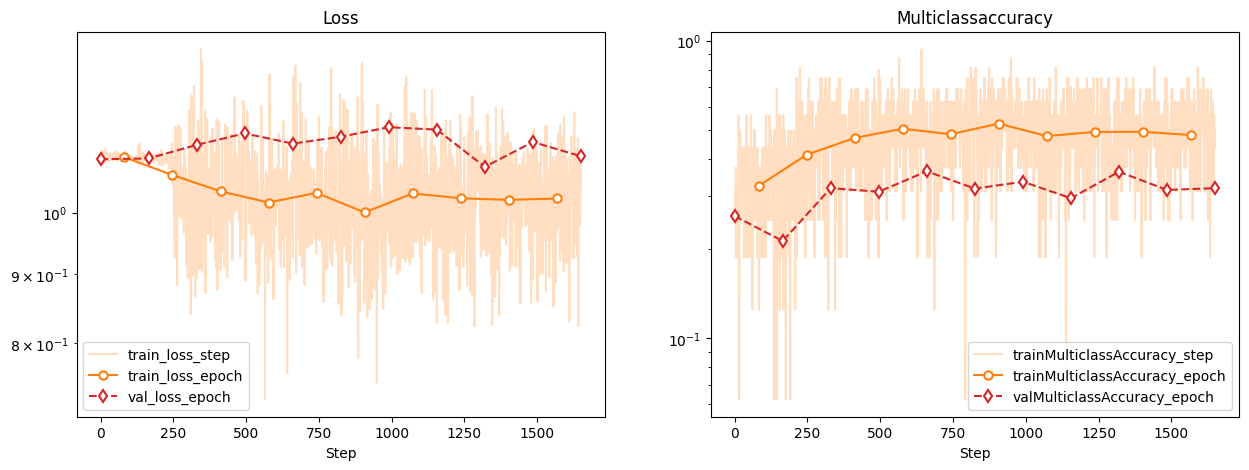

In [9]:
fig, ax = trainer.history.plot()
# fig.savefig(run_dir / "training_curves.png")

best_val_loss = checkpoint_cb.best_model_score.item() if checkpoint_cb.best_model_score is not None else float("inf")
print(best_val_loss)

In [10]:
best_model = dl.CategoricalClassifier.load_from_checkpoint(
    checkpoint_cb.best_model_path
)
best_model.eval()

CategoricalClassifier(
  (loss): CrossEntropyLoss()
  (train_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=test
  )
  (model): GraphToGlobalMPM(
    (encoder): Parallel(
      (0-1): 2 x MultiLayerPerceptron(
        (blocks): LayerList(
          (0): LinearBlock(
            (layer): LazyLinear(in_features=0, out_features=96, bias=True)
            (activation): Identity()
          )
        )
      )
    )
    (backbone): MessagePassingNeuralNetwork(
      (blocks): LayerList(
        (0-3): 4 x TransformPropagateUpdate(
          (transform): Transform(
            (combine): Cat()
            (layer): LazyLinear(in_features=0, out_features=96, bias=True)
            (activation): ReLU()
          )
          (propagate): Sum()
         

              precision    recall  f1-score   support

    endosome       0.56      0.19      0.28       469
       golgi       0.36      0.69      0.48       221
   postgolgi       0.29      0.43      0.34       232

    accuracy                           0.37       922
   macro avg       0.40      0.44      0.37       922
weighted avg       0.44      0.37      0.34       922



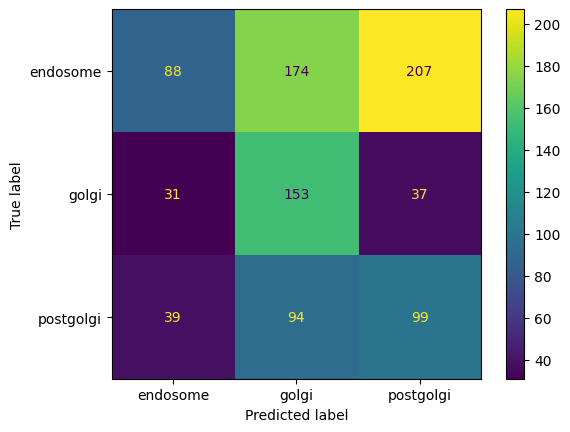

In [11]:
truth, preds = [], []
with torch.no_grad():
    for batch in val_loader:
        y_pred = torch.argmax(best_model(batch), dim=1)
        truth.append(batch.y)
        preds.append(y_pred)

truth = torch.concat(truth).numpy()
preds = torch.concat(preds).numpy()

# Confusion matrix
cm = confusion_matrix(truth, preds)

fig, ax = plt.subplots()
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels).plot(ax=ax)

# Classification report
report = classification_report(truth, preds, target_names=display_labels)
print(report)